In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 
from scipy import stats
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import beta
import json
import glob

In [ ]:
# The dataset was retrieved from https://www.kaggle.com/datasets/leonardocosmote/air-quality-and-environmental-dataset-outdoor-1yr 

json_files = glob.glob("data/2024-02-01_2024-02-29.json")  # all JSON files in 'data' folder: "data/*.json"

# List to store DataFrames
dfs = []

for file in json_files:
    with open(file) as f:
        data = json.load(f)
    df = pd.DataFrame(data["values"], columns=data["columns"])
    
    dfs.append(df)

# Combine all files into one DataFrame
df_all = pd.concat(dfs, ignore_index=True)
df=df_all
df

,time,CO2_ppm,PM10_ug_m3,PM1_ug_m3,PM2_5_ug_m3,application_id,bme_humi,bme_pressure,bme_temp,device_id,...,CH4,CO_ppm,NH3_ppm,NO2_ppm,humidity,temperature,dust_0.3,dust_0.5,dust_1.0,dust_2.5
0,2024-02-01T00:00:05.965629929Z,407.0,6.6,5.0,6.6,AEOLUS,90.87,1004.38,9.81,SenseAir-CO2-10_10,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2024-02-01T00:00:14.166112175Z,NaN,NaN,NaN,NaN,AEOLUS,NaN,NaN,NaN,F4:CF:A2:F5:04:E4,...,970.0,4.285082,0.052657,0.147032,37.099998,24.200001,None,None,None,None
2,2024-02-01T00:00:48.473785604Z,380.0,NaN,NaN,NaN,AEOLUS,15.67,NaN,33.37,8aa5bbea-9181-4e43-8900-dfe4db97f33e,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,2024-02-01T00:00:55.445116738Z,369.0,NaN,NaN,NaN,AEOLUS,48.14,NaN,11.93,91b505eb-f34f-4a18-8631-702ac45e7cce,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,2024-02-01T00:01:07.258336089Z,407.0,5.6,4.4,5.4,AEOLUS,90.44,1004.34,9.23,SenseAir-CO2-10_10,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268082,2024-02-29T23:59:08.568147286Z,NaN,NaN,NaN,NaN,AEOLUS,NaN,NaN,NaN,F4:CF:A2:F5:04:E4,...,955.0,4.364831,0.074755,0.144735,48.599998,26.799999,None,None,None,None
268083,2024-02-29T23:59:23.150039175Z,410.0,20.4,10.8,16.0,AEOLUS,100.00,991.75,15.04,SenseAir-CO2-7_7,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
268084,2024-02-29T23:59:29.044124553Z,349.0,NaN,NaN,NaN,AEOLUS,53.25,NaN,19.71,91b505eb-f34f-4a18-8631-702ac45e7cce,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
268085,2024-02-29T23:59:51.94304707Z,403.0,16.2,10.0,16.0,AEOLUS,100.00,992.09,16.39,SenseAir-CO2-10_10,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


In [173]:
null_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(2)
})
print(null_summary.sort_values('missing_%', ascending=False))

                missing_count  missing_%
dust_2.5               268087     100.00
dust_1.0               268087     100.00
dust_0.5               268087     100.00
dust_0.3               268087     100.00
O3_ug_m3               231186      86.24
O3_ppb                 231186      86.24
humidity               230880      86.12
NH3_ppm                230880      86.12
CO_ppm                 230880      86.12
CH4                    230880      86.12
temperature            230880      86.12
NO2_ppm                230880      86.12
gps_spd                193336      72.12
bme_pressure           193336      72.12
PM1_ug_m3              193336      72.12
PM2_5_ug_m3            185054      69.03
PM10_ug_m3             185054      69.03
sunrise_temp           157141      58.62
long                   134615      50.21
lat                    134615      50.21
CO2_ppm                 82390      30.73
bme_temp                82390      30.73
bme_humi                82390      30.73
room_id         

In [208]:
print('devices: ', df['device_id'].unique())
print('placement: ', df['placement'].unique())
print('application_id: ',df['application_id'].unique())
print('side_id: ',df['site_id'].unique())
print('room_id: ',df['room_id'].unique())

devices:  ['SenseAir-CO2-10_10' 'F4:CF:A2:F5:04:E4'
 '8aa5bbea-9181-4e43-8900-dfe4db97f33e'
 '91b505eb-f34f-4a18-8631-702ac45e7cce'
 '95d67273-bfb0-42d5-be44-446583519e08' '1601065' 'A8:48:FA:CE:E9:A1'
 'SenseAir-CO2-7_7']
placement:  ['outdoor' 'outdoors']
application_id:  ['AEOLUS']
side_id:  ['OTE-ACADEMY' '-' 'elinas_home' 'geohouse' None]
room_id:  ['R211' '-' 'R105' 'balcony' None]


The dataset is high-frequency, multi-sensor, sparse

In [235]:
# Drop not relevant columns for the analysis
columns_to_drop = ["dust_2.5", "dust_1.0", "dust_0.5", "dust_0.3", # These have 100% null values
                   "placement","application_id", # These are similar to every device
                  # "lat","long","site_id","room_id","gps_spd",
                   "PM1_ug_m3","O3_ug_m3","CO2_ppm","CH4","NH3_ppm"] # These are not used to calculate AQI
df = df.drop(columns=columns_to_drop)
df

,time,PM10_ug_m3,PM2_5_ug_m3,bme_humi,bme_pressure,bme_temp,device_id,gps_spd,lat,long,room_id,site_id,sunrise_temp,O3_ppb,CO_ppm,NO2_ppm,humidity,temperature
0,2024-02-01T00:00:05.965629929Z,6.6,6.6,90.87,1004.38,9.81,SenseAir-CO2-10_10,0.01,38.049782,23.788111,R211,OTE-ACADEMY,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01T00:00:14.166112175Z,NaN,NaN,NaN,NaN,NaN,F4:CF:A2:F5:04:E4,NaN,38.049782,23.788099,-,-,NaN,NaN,4.285082,0.147032,37.099998,24.200001
2,2024-02-01T00:00:48.473785604Z,NaN,NaN,15.67,NaN,33.37,8aa5bbea-9181-4e43-8900-dfe4db97f33e,NaN,NaN,NaN,R105,OTE-ACADEMY,26.08,NaN,NaN,NaN,NaN,NaN
3,2024-02-01T00:00:55.445116738Z,NaN,NaN,48.14,NaN,11.93,91b505eb-f34f-4a18-8631-702ac45e7cce,NaN,NaN,NaN,balcony,elinas_home,8.49,NaN,NaN,NaN,NaN,NaN
4,2024-02-01T00:01:07.258336089Z,5.6,5.4,90.44,1004.34,9.23,SenseAir-CO2-10_10,0.01,38.049782,23.788111,R211,OTE-ACADEMY,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268082,2024-02-29T23:59:08.568147286Z,NaN,NaN,NaN,NaN,NaN,F4:CF:A2:F5:04:E4,NaN,38.049675,23.787983,-,-,NaN,NaN,4.364831,0.144735,48.599998,26.799999
268083,2024-02-29T23:59:23.150039175Z,20.4,16.0,100.00,991.75,15.04,SenseAir-CO2-7_7,0.22,38.048595,23.788061,balcony,OTE-ACADEMY,NaN,NaN,NaN,NaN,NaN,NaN
268084,2024-02-29T23:59:29.044124553Z,NaN,NaN,53.25,NaN,19.71,91b505eb-f34f-4a18-8631-702ac45e7cce,NaN,NaN,NaN,balcony,elinas_home,16.09,NaN,NaN,NaN,NaN,NaN
268085,2024-02-29T23:59:51.94304707Z,16.2,16.0,100.00,992.09,16.39,SenseAir-CO2-10_10,0.04,38.049622,23.787973,R211,OTE-ACADEMY,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
# Determine which sensor collect what data
device_ids = df['device_id'].unique()
for dev in device_ids:
    df_dev = df[df['device_id'] == dev]
    print(dev, df_dev.columns[df_dev.notnull().any()].tolist())

SenseAir-CO2-10_10 ['time', 'PM10_ug_m3', 'PM2_5_ug_m3', 'bme_humi', 'bme_pressure', 'bme_temp', 'device_id', 'gps_spd', 'lat', 'long', 'room_id', 'site_id']
F4:CF:A2:F5:04:E4 ['time', 'device_id', 'lat', 'long', 'room_id', 'site_id', 'CO_ppm', 'NO2_ppm', 'humidity', 'temperature']
8aa5bbea-9181-4e43-8900-dfe4db97f33e ['time', 'bme_humi', 'bme_temp', 'device_id', 'room_id', 'site_id', 'sunrise_temp']
91b505eb-f34f-4a18-8631-702ac45e7cce ['time', 'bme_humi', 'bme_temp', 'device_id', 'room_id', 'site_id', 'sunrise_temp']
95d67273-bfb0-42d5-be44-446583519e08 ['time', 'bme_humi', 'bme_temp', 'device_id', 'lat', 'long', 'site_id', 'sunrise_temp']
1601065 ['time', 'PM10_ug_m3', 'PM2_5_ug_m3', 'device_id']
A8:48:FA:CE:E9:A1 ['time', 'device_id', 'site_id', 'O3_ppb']
SenseAir-CO2-7_7 ['time', 'PM10_ug_m3', 'PM2_5_ug_m3', 'bme_humi', 'bme_pressure', 'bme_temp', 'device_id', 'gps_spd', 'lat', 'long', 'room_id', 'site_id']


We will use three devices: SenseAir-CO2-10_10, F4:CF:A2:F5:04:E4, A8:48:FA:CE:E9:A1

In [211]:
device_ids = df['device_id'].unique()
device_dfs = {}  # dictionary to store device-specific DataFrames

for dev in device_ids:
    # Filter rows for this device
    df_dev = df[df['device_id'] == dev].copy()
    
    # Keep only columns that have at least one non-null value
    non_null_cols = df_dev.columns[df_dev.notnull().any()].tolist()
    df_dev = df_dev[non_null_cols]
    
    # Store in dictionary
    device_dfs[dev] = df_dev

In [266]:
df_senseair10=device_dfs[device_ids[0]]
df_senseair10=df_senseair10[["time","PM10_ug_m3","PM2_5_ug_m3","bme_pressure"]].copy()

df_senseair10['time'] = pd.to_datetime(df_senseair10['time'])
df_senseair10['time'] = df_senseair10['time'].dt.round('1s') #Round
df_senseair10 = df_senseair10.sort_values('time') #Sort

df_senseair10.head()

,time,PM10_ug_m3,PM2_5_ug_m3,bme_pressure
0,2024-02-01 00:00:06+00:00,6.6,6.6,1004.38
4,2024-02-01 00:01:07+00:00,5.6,5.4,1004.34
10,2024-02-01 00:02:06+00:00,6.4,6.4,1004.36
15,2024-02-01 00:03:06+00:00,5.6,5.6,1004.33
20,2024-02-01 00:04:07+00:00,3.4,3.4,1004.35


In [280]:
df_F4CFA2F504E4=device_dfs[device_ids[1]]
df_F4CFA2F504E4=df_F4CFA2F504E4[["time","temperature","humidity","CO_ppm","NO2_ppm"]].copy()

df_F4CFA2F504E4['time'] = pd.to_datetime(df_F4CFA2F504E4['time'])
df_F4CFA2F504E4['time'] = df_F4CFA2F504E4['time'].dt.round('1s') #Round
df_F4CFA2F504E4 = df_F4CFA2F504E4.sort_values('time') #Sort

df_F4CFA2F504E4.head()

,time,temperature,humidity,CO_ppm,NO2_ppm
1,2024-02-01 00:00:14+00:00,24.200001,37.099998,4.285082,0.147032
6,2024-02-01 00:01:21+00:00,24.200001,37.000000,4.304882,0.147612
12,2024-02-01 00:02:28+00:00,24.200001,37.200001,4.285082,0.145879
16,2024-02-01 00:03:36+00:00,24.200001,37.000000,4.285082,0.147032
22,2024-02-01 00:04:43+00:00,24.200001,37.099998,4.265372,0.147612


In [281]:
df_A848FACEE9A1=device_dfs[device_ids[6]]
df_A848FACEE9A1=df_A848FACEE9A1[["time","O3_ppb"]].copy()

df_A848FACEE9A1['time'] = pd.to_datetime(df_A848FACEE9A1['time'])
df_A848FACEE9A1['time'] = df_A848FACEE9A1['time'].dt.round('1s') #Round
df_A848FACEE9A1 = df_A848FACEE9A1.sort_values('time') #Sort

df_A848FACEE9A1.head()

,time,O3_ppb
589,2024-02-01 01:58:17+00:00,17.625570
606,2024-02-01 02:01:23+00:00,12.417291
2257,2024-02-01 07:39:46+00:00,8.466639
2275,2024-02-01 07:42:52+00:00,10.560774
3009,2024-02-01 10:11:17+00:00,12.649059


multi-sensor fusion

In [ ]:
# Merge dataframes allowing ±60 seconds difference
merged12 = pd.merge_asof(
    df_senseair10, df_F4CFA2F504E4,
    on='time',
    direction='nearest',           # nearest timestamp
    tolerance=pd.Timedelta('60s')  # maximum allowed difference
)

# Merge the last dataframe into the result
merged = pd.merge_asof(
    merged12, df_A848FACEE9A1,
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta('60s')
)
merged=merged.dropna()
print(len(merged))
merged.head()

39119


,time,PM10_ug_m3,PM2_5_ug_m3,bme_pressure,temperature,humidity,CO_ppm,NO2_ppm,O3_ppb
117,2024-02-01 01:58:06+00:00,5.8,5.8,1003.74,22.600000,37.700001,4.265372,0.147032,17.625570
118,2024-02-01 01:59:06+00:00,7.7,7.7,1003.84,22.700001,38.000000,4.265372,0.146454,17.625570
120,2024-02-01 02:01:06+00:00,8.2,8.2,1003.75,22.700001,37.200001,4.265372,0.147032,12.417291
121,2024-02-01 02:02:06+00:00,9.2,9.2,1003.75,22.600000,37.599998,4.245753,0.147032,12.417291
456,2024-02-01 07:39:06+00:00,11.2,11.2,1003.78,26.000000,33.099998,4.091978,0.152938,8.466639


In [283]:
null_summary = pd.DataFrame({
    'missing_count': merged.isnull().sum(),
    'missing_%': (merged.isnull().mean() * 100).round(2)
})
print(null_summary.sort_values('missing_%', ascending=False))

              missing_count  missing_%
time                      0        0.0
PM10_ug_m3                0        0.0
PM2_5_ug_m3               0        0.0
bme_pressure              0        0.0
temperature               0        0.0
humidity                  0        0.0
CO_ppm                    0        0.0
NO2_ppm                   0        0.0
O3_ppb                    0        0.0


In [ ]:
# Save to csv
merged.to_csv("sensor_data.csv", index=False)

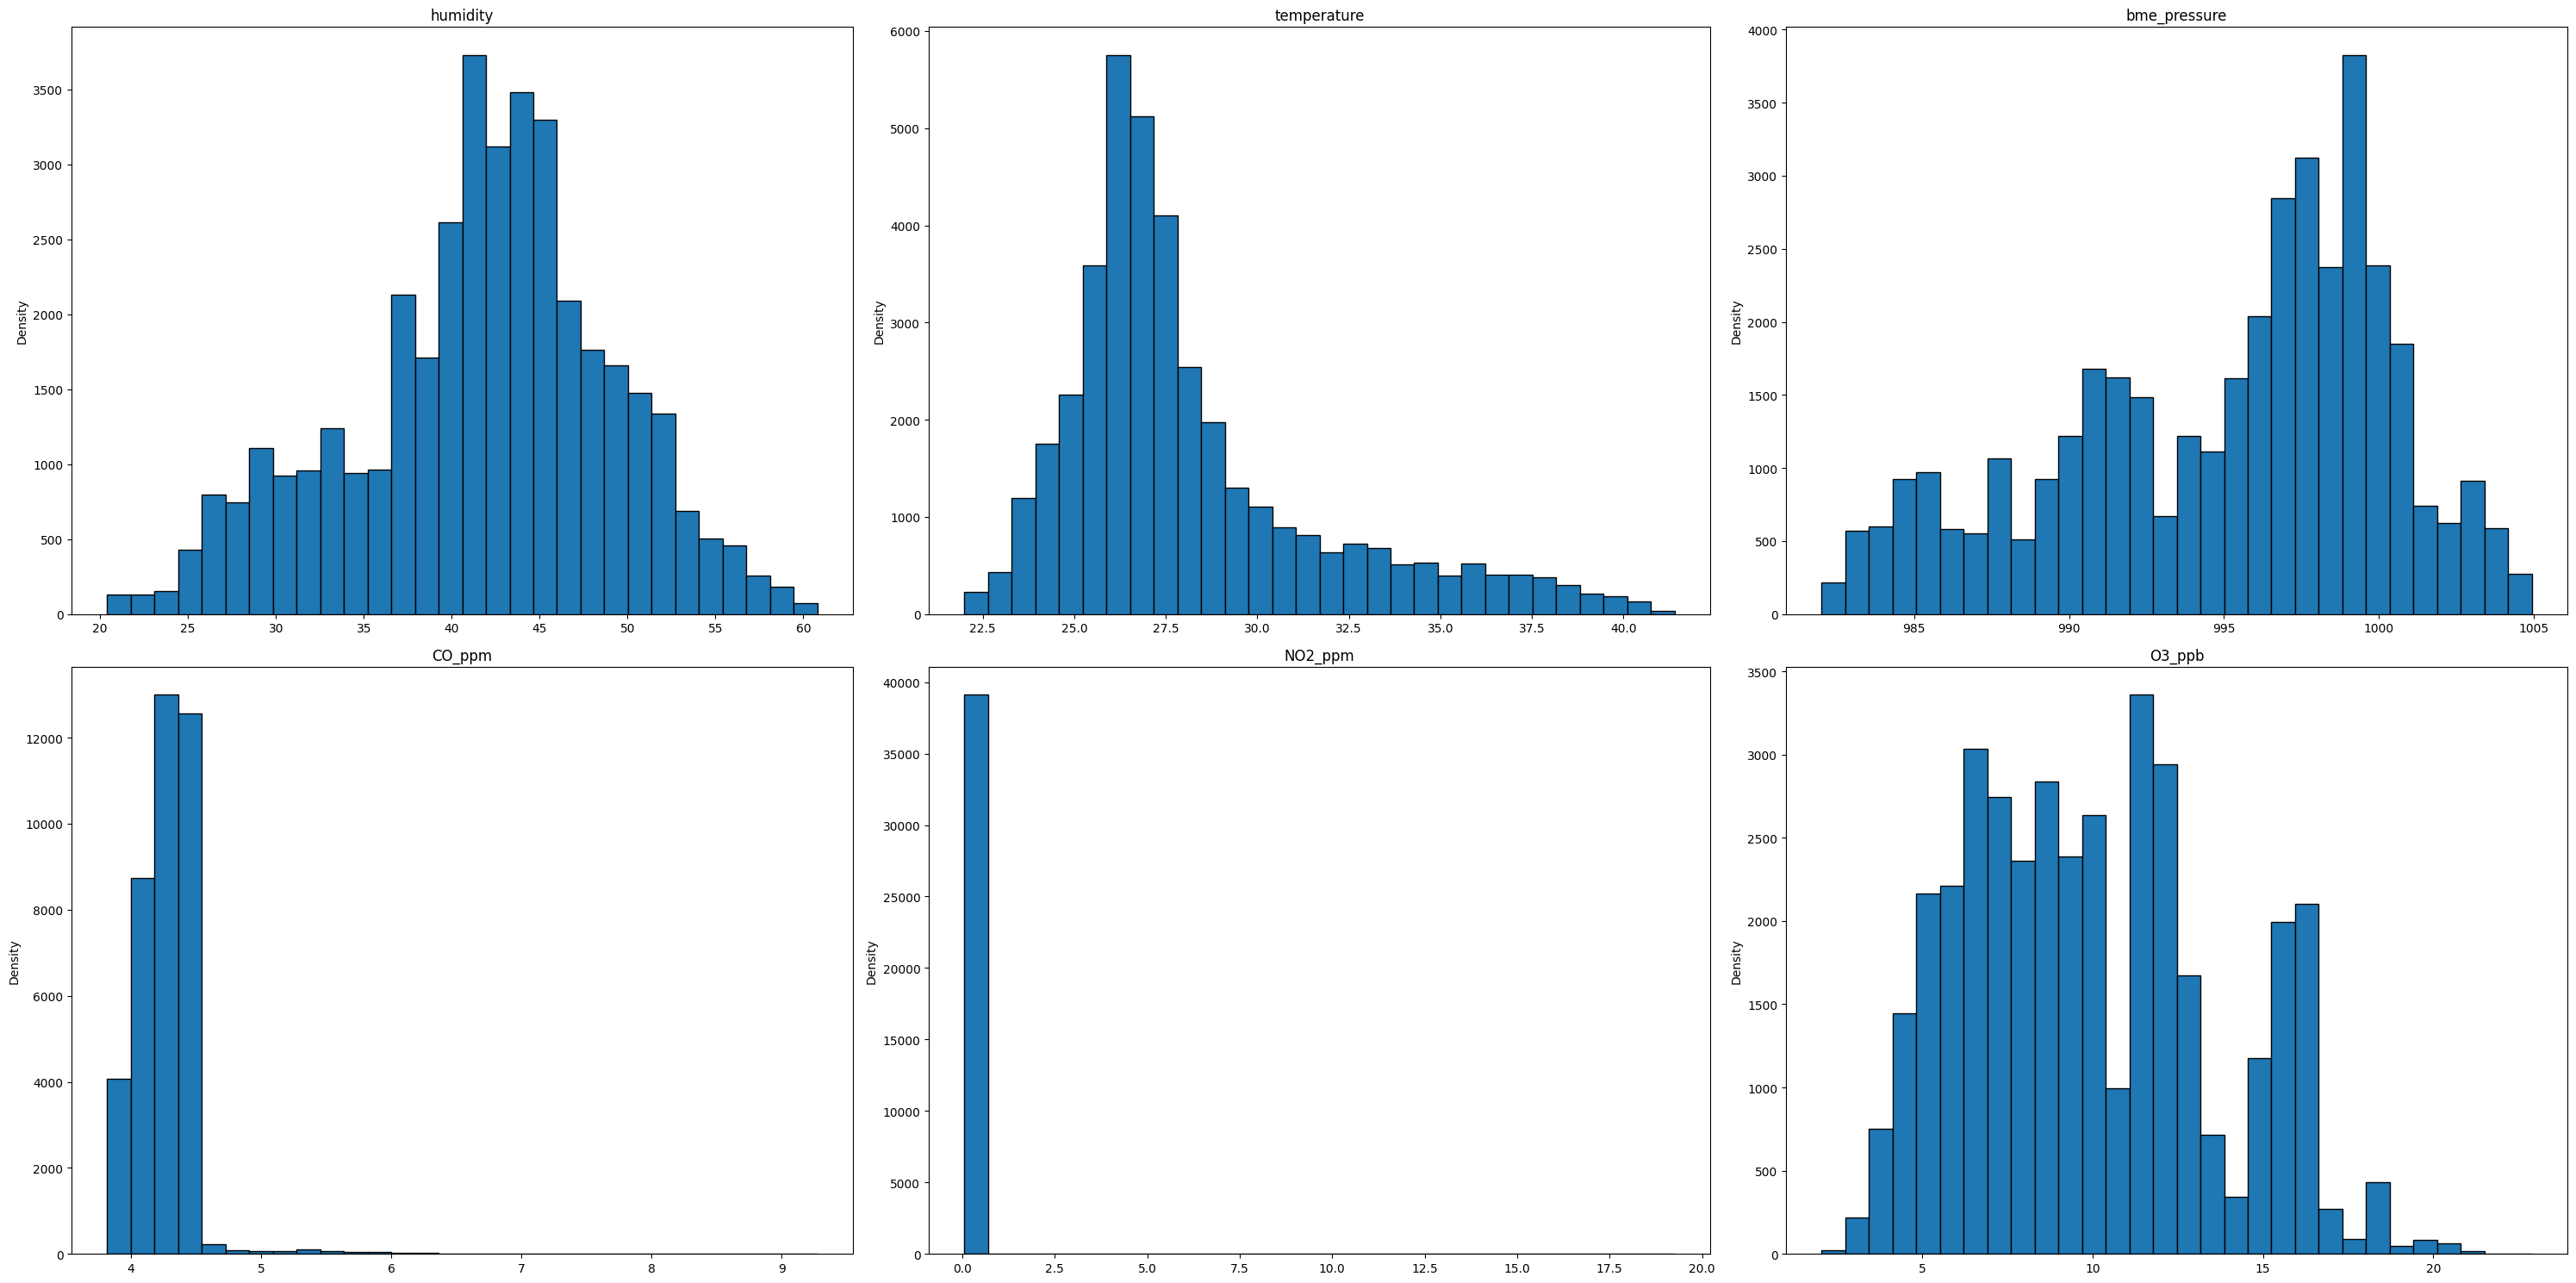

In [289]:
columns = ["humidity","temperature", "bme_pressure","CO_ppm","NO2_ppm","O3_ppb"]

fig, axes = plt.subplots(2, 3, figsize=(30, 15))  # 2 rows, 3 columns
axes = axes.flatten()  # flatten 2D array to 1D for easy indexing

# Plot each column
for i, col in enumerate(columns):
    axes[i].hist(merged[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()